In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
os.chdir('/content/drive/MyDrive/BUDT757/BUDT757 Group 3 Project/')
#

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('Data/enron_spam_data.csv')

Date range

In [ ]:
print("Min Date: ", df['Date'].min())
print("Max Date: ", df['Date'].max())

Min Date:  1999-12-10
Max Date:  2005-09-06


Base line Naive Bayes Split by year

In [ ]:
import pandas as pd
import numpy as np
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score
from sklearn.pipeline import Pipeline

import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

# ---- Clean dataset ----
df = df.dropna(subset=["Message", "Spam/Ham"])

# ---- Text cleaning function ----
stop_words = set(stopwords.words("english"))

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)                  # remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)

df["clean_text"] = df["Message"].apply(preprocess_text)

# ---- Train-test split based on years ----
cutoff_year = 2002
# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Drop rows where date parsing failed
df = df.dropna(subset=["Date"])

# Extract year
df["Year"] = df["Date"].dt.year


print(df["Year"].value_counts().sort_index())
train_df = df[df["Year"] <= cutoff_year]
test_df  = df[df["Year"] > cutoff_year]

label_map = {"ham": 0, "spam": 1}
train_df["label"] = train_df["Spam/Ham"].map(label_map)
test_df["label"] = test_df["Spam/Ham"].map(label_map)
X_train = train_df["clean_text"]   # or combine Subject + Message
y_train = train_df["label"]

X_test = test_df["clean_text"]
y_test = test_df["label"]
# X_train, X_test, y_train, y_test = train_test_split(
#     df["clean_text"],
#     df["Spam/Ham"],
#     test_size=0.2,
#     random_state=42,
#     stratify=df["Spam/Ham"]
# )

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Year
1999     135
2000    6753
2001    8387
2002    2593
2003     102
2004    5841
2005    9534
Name: count, dtype: int64


/tmp/ipykernel_546/748328490.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df["label"] = train_df["Spam/Ham"].map(label_map)
/tmp/ipykernel_546/748328490.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df["label"] = test_df["Spam/Ham"].map(label_map)


In [ ]:
# ---- Build pipeline ----
nb_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=5000,
        ngram_range=(1,2),     # unigrams + bigrams
        min_df=2,
        max_df=0.9
    )),
    ("nb", MultinomialNB(alpha=1.0))
])

# ---- Train ----
nb_model.fit(X_train, y_train)

# ---- Predict ----
y_pred = nb_model.predict(X_test)

# ---- Evaluate ----
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5230341797505976
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.52      0.69     15477

    accuracy                           0.52     15477
   macro avg       0.50      0.26      0.34     15477
weighted avg       1.00      0.52      0.69     15477



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
def get_nb_model_size(model):
    size = 0
    size += model.class_count_.nbytes
    size += model.class_log_prior_.nbytes
    size += model.feature_count_.nbytes
    size += model.feature_log_prob_.nbytes
    return size / (1024 ** 2)  # MB

print("Naive Bayes parameter memory (MB):", get_nb_model_size(nb_model[1]))

Naive Bayes parameter memory (MB): 0.152618408203125


Now we test against a conceptual drift of spam 2021 emails

In [ ]:
!pip install py7zr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.3/71.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.2/494.2 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.6/100.6 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 13.3 MB/s eta 0:00:00


In [ ]:
import py7zr

archive_path = "Data/2021.7z"
extract_path = "spam_data_2021"

with py7zr.SevenZipFile(archive_path, mode='r') as z:
    z.extractall(path=extract_path)

print("Extraction complete.")

Extraction complete.


In [ ]:
import os
import pandas as pd

base_path = "spam_data_2021/2021"

rows = []

for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.endswith(".txt"):
            file_path = os.path.join(root, file)

            with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
                text = f.read()

            # Extract month from folder name
            month = os.path.basename(root)

            rows.append({
                "month": month,
                "filename": file,
                "text": text
            })



In [ ]:
bruce = pd.DataFrame(rows)

bruce.head()

,month,filename,text
0,01,1610749396.1276270_15.txt,Return-Path: <servicebtc@adn.com>\nDelivered-T...
1,01,1610749396.1276270_17.txt,Return-Path: <gutterprotectorco_promotion-bruc...
2,01,1610749396.1276270_19.txt,Return-Path: <ThreeDimensionalRug-bruce=untrou...
3,01,1610749396.1276270_21.txt,Return-Path: <linux-kernel-owner@vger.kernel.o...
4,01,1610749396.1276270_23.txt,Return-Path: <linux-kernel-owner@vger.kernel.o...


In [ ]:
import email
from email import policy
from email.parser import BytesParser
from email.header import decode_header
from io import BytesIO

In [ ]:
def decode_mime_header(value):
    if not value:
        return None

    decoded_parts = decode_header(value)
    decoded_string = ""

    for part, enc in decoded_parts:
        if isinstance(part, bytes):
            decoded_string += part.decode(enc or "utf-8", errors="ignore")
        else:
            decoded_string += part

    return decoded_string

In [ ]:
import codecs

def safe_decode(payload, charset):
    if not payload:
        return ""

    # Normalize invalid charset values
    if not charset:
        charset = "utf-8"

    try:
        codecs.lookup(charset)
    except LookupError:
        charset = "utf-8"

    return payload.decode(charset, errors="ignore")


def extract_body(msg):
    if msg.is_multipart():
        for part in msg.walk():
            if part.get_content_type() == "text/plain":
                payload = part.get_payload(decode=True)
                return safe_decode(payload, part.get_content_charset())

        for part in msg.walk():
            if part.get_content_type() == "text/html":
                payload = part.get_payload(decode=True)
                return safe_decode(payload, part.get_content_charset())
    else:
        payload = msg.get_payload(decode=True)
        return safe_decode(payload, msg.get_content_charset())

In [ ]:
def parse_email(raw_text):
    msg = BytesParser(policy=policy.default).parse(
        BytesIO(raw_text.encode("utf-8", errors="ignore"))
    )

    return pd.Series({
        "message_id": msg.get("Message-ID"),
        "subject": decode_mime_header(msg.get("Subject")),
        "body": extract_body(msg)
    })

parsed = bruce["text"].apply(parse_email)

bruce_w = pd.concat([bruce, parsed], axis=1)

bruce_w.head()

,month,filename,text,message_id,subject,body
0,01,1610749396.1276270_15.txt,Return-Path: <servicebtc@adn.com>\nDelivered-T...,None,Fordert_besseren_Schlaf,"<HTML><HEAD></HEAD>\n<BODY>\n<P><A href=""https..."
1,01,1610749396.1276270_17.txt,Return-Path: <gutterprotectorco_promotion-bruc...,<0.0.0.36.1D6EB7AB70F86EC.58EA18@mail.rwardtv....,Gutter Protector is about to spill their summe...,<html>\n <head> \n <title>unobserved</title> ...
2,01,1610749396.1276270_19.txt,Return-Path: <ThreeDimensionalRug-bruce=untrou...,<73c7fc7b-f6bf-4bd0-8eaf-d8b07fcc881e@unioncas...,Hilarious and eye-catching rug will be the hig...,
3,01,1610749396.1276270_21.txt,Return-Path: <linux-kernel-owner@vger.kernel.o...,<CADmhhyxkxOK-+JF_Sbw=mgLKnxd3ErYAYuL8R2T6KA00...,I Need Your Assistance,Let me start by introducing myself my name is ...
4,01,1610749396.1276270_23.txt,Return-Path: <linux-kernel-owner@vger.kernel.o...,<CAF+m9ZASY+PbDv0Vmx-Y24pwGTCdd6afjQUs7Jkj4GMY...,OK.........................,"Dear Friend,\n\nAn oil business man made a fix..."


In [ ]:
bruce_w.to_csv('bruce_w.csv', index=False)

In [ ]:
bruce_w = pd.read_csv('bruce_w.csv')

In [ ]:
spam_text = bruce_w['body']

In [ ]:
spam_df = pd.DataFrame(
    {"col": [1] * len(spam_text)},
    index=spam_text.index
)

In [ ]:
spam_text.dropna(inplace=True)
y_pred = nb_model.predict(spam_text)

In [ ]:
print(len(y_pred))
print("Accuracy:", accuracy_score(spam_df[:len(y_pred)], y_pred))

18243
Accuracy: 0.45562681576495095


# Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
lr_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=5000,
        ngram_range=(1,2),
        min_df=2,
        max_df=0.9
    )),
    ("lr", LogisticRegression(
        max_iter=1000,
        solver="liblinear",
        random_state=42
    ))
])

In [ ]:
lr_model.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.9, max_features=5000, min_df=2,
                                 ngram_range=(1, 2))),
                ('lr',
                 LogisticRegression(max_iter=1000, random_state=42,
                                    solver='liblinear'))])

In [ ]:
from sklearn.metrics import f1_score

In [ ]:
lr_clean_pred = lr_model.predict(X_test)
lr_clean_proba = lr_model.predict_proba(X_test)

lr_clean_acc = accuracy_score(y_test, lr_clean_pred)
lr_clean_f1 = f1_score(y_test, lr_clean_pred)
lr_clean_conf = lr_clean_proba.max(axis=1).mean()

print("LR Clean Accuracy:", lr_clean_acc)

LR Clean Accuracy: 0.21063513600827033


In [ ]:
y_pred = lr_model.predict(spam_text)

In [ ]:
print("Accuracy:", accuracy_score(spam_df[:len(y_pred)], y_pred))


Accuracy: 0.04988214657676917


# DistilBert

In [ ]:
!pip install transformers datasets accelerate evaluate -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.8 MB/s eta 0:00:00


In [ ]:
import torch
import numpy as np
import random

# Reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [ ]:
import pandas as pd

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.dropna(subset=["Date"])
df["Year"] = df["Date"].dt.year

cutoff_year = 2002
train_df = df[df["Year"] <= cutoff_year]
test_df  = df[df["Year"] > cutoff_year]

train_df["text"] = train_df["Subject"].fillna("") + " " + train_df["Message"].fillna("")
test_df["text"]  = test_df["Subject"].fillna("") + " " + test_df["Message"].fillna("")

# Convert labels to numeric
label_map = {"ham": 0, "spam": 1}
train_df["label"] = train_df["Spam/Ham"].map(label_map)
test_df["label"] = test_df["Spam/Ham"].map(label_map)

print(len(train_df), len(test_df))

17868 15477


/tmp/ipykernel_546/3107055652.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df["text"] = train_df["Subject"].fillna("") + " " + train_df["Message"].fillna("")
/tmp/ipykernel_546/3107055652.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df["text"]  = test_df["Subject"].fillna("") + " " + test_df["Message"].fillna("")
/tmp/ipykernel_546/3107055652.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] =

In [ ]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(train_df[["text", "label"]])
test_dataset  = Dataset.from_pandas(test_df[["text", "label"]])

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
).to(device)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=256
    )

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset  = test_dataset.map(tokenize, batched=True)

train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])

Map:   0%|          | 0/17868 [00:00<?, ? examples/s]

Map:   0%|          | 0/15477 [00:00<?, ? examples/s]

In [ ]:
from transformers import TrainingArguments, Trainer
import evaluate

metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": (predictions == labels).mean()
    }

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="no",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,  # Start small
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=100,
    seed=42
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.013368,0.575950,0.877043
2,0.006092,1.762763,0.713510


TrainOutput(global_step=2234, training_loss=0.02537234020798785, metrics={'train_runtime': 1220.2757, 'train_samples_per_second': 29.285, 'train_steps_per_second': 1.831, 'total_flos': 2366927479185408.0, 'train_loss': 0.02537234020798785, 'epoch': 2.0})

In [ ]:
results = trainer.evaluate()
print(results)

{'eval_loss': 1.7627633810043335, 'eval_accuracy': 0.7135103702267881, 'eval_runtime': 136.9665, 'eval_samples_per_second': 112.998, 'eval_steps_per_second': 7.067, 'epoch': 2.0}


In [ ]:
print("GPU memory allocated:",
      torch.cuda.memory_allocated() / 1024**3, "GB")

GPU memory allocated: 0.7882428169250488 GB


In [ ]:
model.eval()

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained("bert_spam_model")
tokenizer = AutoTokenizer.from_pretrained("bert_spam_model")


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [ ]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [ ]:
# Convert to list of clean strings
spam_text_clean = (
    spam_text
    .dropna()              # remove missing values
    .astype(str)           # ensure all entries are strings
    .tolist()
)

In [ ]:
import torch

import torch
from math import ceil

batch_size = 32
all_preds = []

model.eval()

for i in range(0, len(spam_text_clean), batch_size):
    batch_texts = spam_text_clean[i:i+batch_size]

    encodings = tokenizer(
        batch_texts,
        truncation=True,
        padding=True,
        max_length=256,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = model(**encodings)
        preds = torch.argmax(outputs.logits, dim=1)

    all_preds.extend(preds.cpu().numpy())

y_pred_bert = all_preds

In [ ]:
from sklearn.metrics import accuracy_score
print(len(bruce_w['body']))
print(len(y_pred_bert))
print("Accuracy:", accuracy_score(spam_df[:len(y_pred_bert)], y_pred_bert))

18607
18243
Accuracy: 0.37493833251110015


In [ ]:
model.save_pretrained("bert_spam_model")
tokenizer.save_pretrained("bert_spam_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('bert_spam_model/tokenizer_config.json', 'bert_spam_model/tokenizer.json')

# Evasion

In [ ]:
import random
import re

def misspell_attack(text):
    replacements = {
        "free": "fr33",
        "click": "cl1ck",
        "offer": "0ffer",
        "money": "m0ney",
        "win": "w1n"
    }
    for k, v in replacements.items():
        text = re.sub(rf"\b{k}\b", v, text, flags=re.IGNORECASE)
    return text


def case_attack(text):
    return "".join(
        c.upper() if random.random() > 0.5 else c.lower()
        for c in text
    )


def padding_attack(text):
    padding = " meeting schedule project discussion quarterly analysis update"
    return text + padding


def special_char_attack(text):
    return re.sub(r"[aeiou]", lambda m: m.group(0) + "!", text)

In [ ]:
subset_size = 1000

test_subset = test_df.sample(subset_size, random_state=42).copy()

attacks = {
    "clean": lambda x: x,
    "misspell": misspell_attack,
    "case": case_attack,
    "padding": padding_attack,
    "special_char": special_char_attack
}

attacked_sets = {}

for name, attack_fn in attacks.items():
    attacked_sets[name] = test_subset["text"].apply(attack_fn)

In [ ]:
nb_results = {}

for name, texts in attacked_sets.items():
    preds = nb_model.predict(texts)
    probs = nb_model.predict_proba(texts)

    acc = accuracy_score(test_subset["label"], preds)
    f1 = f1_score(test_subset["label"], preds)
    confidence = probs.max(axis=1).mean()

    nb_results[name] = {
        "accuracy": acc,
        "f1": f1,
        "confidence": confidence
    }

nb_results

{'clean': {'accuracy': 0.537,
  'f1': 0.6987638256343527,
  'confidence': np.float64(0.7574612756098777)},
 'misspell': {'accuracy': 0.51,
  'f1': 0.6754966887417219,
  'confidence': np.float64(0.7512060436689417)},
 'case': {'accuracy': 0.537,
  'f1': 0.6987638256343527,
  'confidence': np.float64(0.7574612756098777)},
 'padding': {'accuracy': 0.282,
  'f1': 0.43993759750390016,
  'confidence': np.float64(0.8285568706228732)},
 'special_char': {'accuracy': 0.002,
  'f1': 0.003992015968063872,
  'confidence': np.float64(0.8290957709696144)}}

In [ ]:
lr_results = {}

for name, texts in attacked_sets.items():
    preds = lr_model.predict(texts)
    probs = lr_model.predict_proba(texts)

    acc = accuracy_score(test_subset["label"], preds)
    f1 = f1_score(test_subset["label"], preds)
    confidence = probs.max(axis=1).mean()

    lr_results[name] = {
        "accuracy": acc,
        "f1": f1,
        "confidence": confidence
    }

lr_results

{'clean': {'accuracy': 0.239,
  'f1': 0.38579499596448746,
  'confidence': np.float64(0.75766843735901)},
 'misspell': {'accuracy': 0.137,
  'f1': 0.24098504837291118,
  'confidence': np.float64(0.767989960022792)},
 'case': {'accuracy': 0.239,
  'f1': 0.38579499596448746,
  'confidence': np.float64(0.75766843735901)},
 'padding': {'accuracy': 0.124,
  'f1': 0.2206405693950178,
  'confidence': np.float64(0.8214273816595857)},
 'special_char': {'accuracy': 0.001,
  'f1': 0.001998001998001998,
  'confidence': np.float64(0.877809114291387)}}

In [ ]:
import torch
import numpy as np

def evaluate_bert(texts):
    encodings = tokenizer(
        list(texts),
        truncation=True,
        padding=True,
        max_length=256,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = model(**encodings)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=1)

    preds = torch.argmax(probs, dim=1).cpu().numpy()
    confidence = probs.max(dim=1).values.mean().item()

    return preds, confidence

In [ ]:
bert_results = {}

for name, texts in attacked_sets.items():
    preds, confidence = evaluate_bert(texts)

    acc = accuracy_score(test_subset["label"], preds)
    f1 = f1_score(test_subset["label"], preds)

    bert_results[name] = {
        "accuracy": acc,
        "f1": f1,
        "confidence": confidence
    }

bert_results

{'clean': {'accuracy': 0.711,
  'f1': 0.831092928112215,
  'confidence': 0.9721149206161499},
 'misspell': {'accuracy': 0.696,
  'f1': 0.8207547169811321,
  'confidence': 0.9711006283760071},
 'case': {'accuracy': 0.711,
  'f1': 0.831092928112215,
  'confidence': 0.972115159034729},
 'padding': {'accuracy': 0.566,
  'f1': 0.722860791826309,
  'confidence': 0.9742174744606018},
 'special_char': {'accuracy': 0.947,
  'f1': 0.9727786337955829,
  'confidence': 0.9784753918647766}}

In [ ]:
import pandas as pd

def build_comparison_table(nb_results, lr_results, bert_results):
    rows = []

    attacks = nb_results.keys()

    for attack in attacks:
        rows.append({
            "Attack": attack,
            "NB Accuracy": nb_results[attack]["accuracy"],
            "LR Accuracy": lr_results[attack]["accuracy"],
            "BERT Accuracy": bert_results[attack]["accuracy"],
            "NB Confidence": nb_results[attack]["confidence"],
            "LR Confidence": lr_results[attack]["confidence"],
            "BERT Confidence": bert_results[attack]["confidence"],
        })

    return pd.DataFrame(rows)

In [ ]:
comparison_table = build_comparison_table(
    nb_results,
    lr_results,
    bert_results
)

comparison_table

,Attack,NB Accuracy,LR Accuracy,BERT Accuracy,NB Confidence,LR Confidence,BERT Confidence
0,clean,0.537,0.239,0.711,0.757461,0.757668,0.972115
1,misspell,0.510,0.137,0.696,0.751206,0.767990,0.971101
2,case,0.537,0.239,0.711,0.757461,0.757668,0.972115
3,padding,0.282,0.124,0.566,0.828557,0.821427,0.974217
4,special_char,0.002,0.001,0.947,0.829096,0.877809,0.978475


In [ ]:
clean_nb = nb_results["clean"]["accuracy"]
clean_bert = bert_results["clean"]["accuracy"]
clean_logit = lr_results["clean"]["accuracy"]
for attack in nb_results:
    print("Attack:", attack)
    print("NB Δ:", clean_nb - nb_results[attack]["accuracy"])
    print("BERT Δ:", clean_bert - bert_results[attack]["accuracy"])
    print("LR Δ:", clean_logit - lr_results[attack]["accuracy"])
    print()

Attack: clean
NB Δ: 0.0
BERT Δ: 0.0
LR Δ: 0.0

Attack: misspell
NB Δ: 0.027000000000000024
BERT Δ: 0.015000000000000013
LR Δ: 0.10199999999999998

Attack: case
NB Δ: 0.0
BERT Δ: 0.0
LR Δ: 0.0

Attack: padding
NB Δ: 0.25500000000000006
BERT Δ: 0.14500000000000002
LR Δ: 0.11499999999999999

Attack: special_char
NB Δ: 0.535
BERT Δ: -0.236
LR Δ: 0.238



# Confidence Shift with concept drift

#### Naive Bayes

In [ ]:
# Validation predictions
nb_val_proba = nb_model.predict_proba(X_test)
nb_val_conf = nb_val_proba.max(axis=1)

# Test predictions
nb_test_proba = nb_model.predict_proba(spam_text)
nb_test_conf = nb_test_proba.max(axis=1)

print("Validation mean confidence:", nb_val_conf.mean())
print("Test mean confidence:", nb_test_conf.mean())
print("Confidence shift:", nb_test_conf.mean() - nb_val_conf.mean())

Validation mean confidence: 0.7614659166080181
Test mean confidence: 0.7297306956883565
Confidence shift: -0.03173522091966163


In [ ]:
import numpy as np

def summarize_conf(conf):
    return {
        "mean": np.mean(conf),
        "std": np.std(conf),
        "min": np.min(conf),
        "25%": np.percentile(conf, 25),
        "50%": np.median(conf),
        "75%": np.percentile(conf, 75),
        "max": np.max(conf),
    }

print("Validation confidence stats:", summarize_conf(nb_val_conf))
print("Test confidence stats:", summarize_conf(nb_test_conf))

Validation confidence stats: {'mean': np.float64(0.7744515822233208), 'std': np.float64(0.13976071177316532), 'min': np.float64(0.5000501158881104), '25%': np.float64(0.6583650294068948), '50%': np.float64(0.800611505655837), '75%': np.float64(0.8970272208868543), 'max': np.float64(0.997171643342601)}
Test confidence stats: {'mean': np.float64(0.8374729464167342), 'std': np.float64(0.10882432045782067), 'min': np.float64(0.5000186336661168), '25%': np.float64(0.7968069851114385), '50%': np.float64(0.8619355440536118), '75%': np.float64(0.9175412210015423), 'max': np.float64(0.995232278580888)}


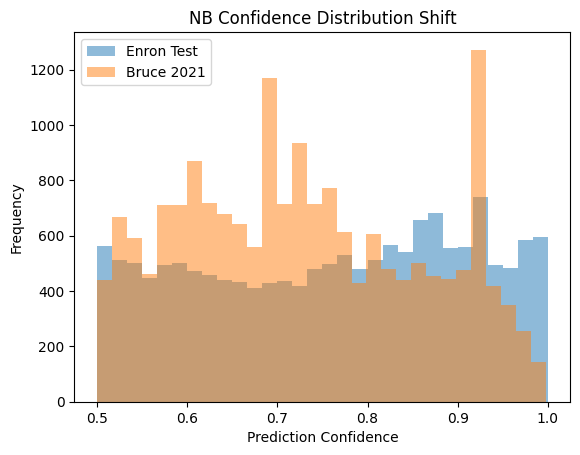

In [ ]:
import matplotlib.pyplot as plt

plt.hist(nb_val_conf, bins=30, alpha=0.5, label="Enron Test")
plt.hist(nb_test_conf, bins=30, alpha=0.5, label="Bruce 2021")
plt.legend()
plt.xlabel("Prediction Confidence")
plt.ylabel("Frequency")
plt.title("NB Confidence Distribution Shift")
plt.show()

In [ ]:
from sklearn.metrics import brier_score_loss

val_brier = brier_score_loss(y_test, val_proba[:,1])
test_brier = brier_score_loss(spam_df[:len(test_proba)], test_proba[:,1])

print("Validation Brier:", val_brier)
print("Test Brier:", test_brier)

Validation Brier: 0.540074394881143
Test Brier: 0.6992297686881503


#### Logistic Regression

In [ ]:
# Validation predictions
lr_val_proba = lr_model.predict_proba(X_test)
lr_val_conf = lr_val_proba.max(axis=1)

# Test predictions
lr_test_proba = lr_model.predict_proba(spam_text)
lr_test_conf = lr_test_proba.max(axis=1)

print("Validation mean confidence:", lr_val_conf.mean())
print("Test mean confidence:", lr_test_conf.mean())
print("Confidence shift:", lr_test_conf.mean() - lr_val_conf.mean())

Validation mean confidence: 0.7744624905601512
Test mean confidence: 0.8375457222573975
Confidence shift: 0.06308323169724639


In [ ]:
print("Validation confidence stats:", summarize_conf(lr_val_conf))
print("Test confidence stats:", summarize_conf(lr_test_conf))

Validation confidence stats: {'mean': np.float64(0.7744515822233208), 'std': np.float64(0.13976071177316532), 'min': np.float64(0.5000501158881104), '25%': np.float64(0.6583650294068948), '50%': np.float64(0.800611505655837), '75%': np.float64(0.8970272208868543), 'max': np.float64(0.997171643342601)}
Test confidence stats: {'mean': np.float64(0.8374729464167342), 'std': np.float64(0.10882432045782067), 'min': np.float64(0.5000186336661168), '25%': np.float64(0.7968069851114385), '50%': np.float64(0.8619355440536118), '75%': np.float64(0.9175412210015423), 'max': np.float64(0.995232278580888)}


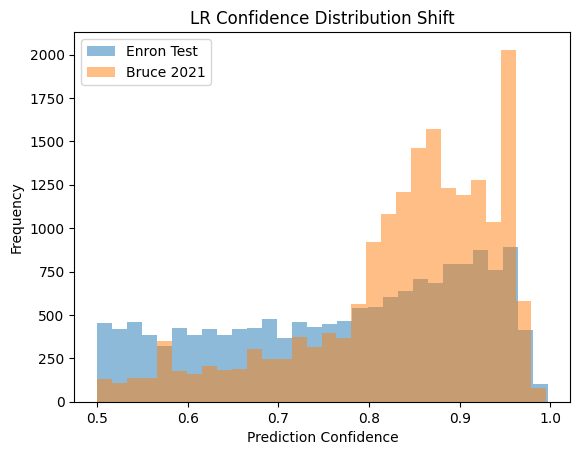

In [ ]:
import matplotlib.pyplot as plt

plt.hist(lr_val_conf, bins=30, alpha=0.5, label="Enron Test")
plt.hist(lr_test_conf, bins=30, alpha=0.5, label="Bruce 2021")
plt.legend()
plt.xlabel("Prediction Confidence")
plt.ylabel("Frequency")
plt.title("LR Confidence Distribution Shift")
plt.show()

In [ ]:
from sklearn.metrics import brier_score_loss

lr_val_brier = brier_score_loss(y_test, lr_val_proba[:,1])
lr_test_brier = brier_score_loss(spam_df[:len(lr_test_proba)], lr_test_proba[:,1])

print("Validation Brier:", lr_val_brier)
print("Test Brier:", lr_test_brier)

Validation Brier: 0.5400916077191725
Test Brier: 0.6993174508242803


#### DistilBert

In [ ]:
import torch
import numpy as np
from torch.nn.functional import softmax

def get_confidence(model, dataloader, device):
    model.eval()
    confidences = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            outputs = model(input_ids=input_ids,
                            attention_mask=attention_mask)

            logits = outputs.logits
            probs = softmax(logits, dim=1)

            batch_conf = probs.max(dim=1).values
            confidences.extend(batch_conf.cpu().numpy())

    return np.array(confidences)

In [ ]:
from torch.utils.data import DataLoader


X_val = X_test.copy().reset_index(drop=True)
X_test_final = spam_text.copy().reset_index(drop=True)

class SpamDataset(torch.utils.data.Dataset):
    def __init__(self, texts):
        self.texts = texts

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return self.texts.iloc[idx]

def collate_fn(batch):
    encoding = tokenizer(
        batch,
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )

    return {
        "input_ids": encoding["input_ids"],
        "attention_mask": encoding["attention_mask"]
    }

val_dataset = SpamDataset(X_val)
test_dataset = SpamDataset(X_test_final)

val_dataloader = DataLoader(val_dataset, batch_size=32, collate_fn=collate_fn)
test_dataloader = DataLoader(test_dataset, batch_size=32, collate_fn=collate_fn)

bert_val_conf = get_confidence(model, val_dataloader, device)
bert_test_conf = get_confidence(model, test_dataloader, device)

print("Validation mean confidence:", bert_val_conf.mean())
print("Test mean confidence:", bert_test_conf.mean())
print("Confidence shift:", bert_test_conf.mean() - bert_val_conf.mean())

Validation mean confidence: 0.97686964
Test mean confidence: 0.95526224
Confidence shift: -0.021607399


In [ ]:
print("Validation stats:", summarize_conf(bert_val_conf))
print("Test stats:", summarize_conf(bert_test_conf))

Validation stats: {'mean': np.float32(0.97686964), 'std': np.float32(0.07332915), 'min': np.float32(0.50012904), '25%': np.float32(0.9963045), '50%': np.float32(0.99865615), '75%': np.float32(0.9990013), 'max': np.float32(0.9999298)}
Test stats: {'mean': np.float32(0.95526224), 'std': np.float32(0.10148974), 'min': np.float32(0.50134945), '25%': np.float32(0.9780877), '50%': np.float32(0.9983133), '75%': np.float32(0.99957687), 'max': np.float32(0.9999496)}


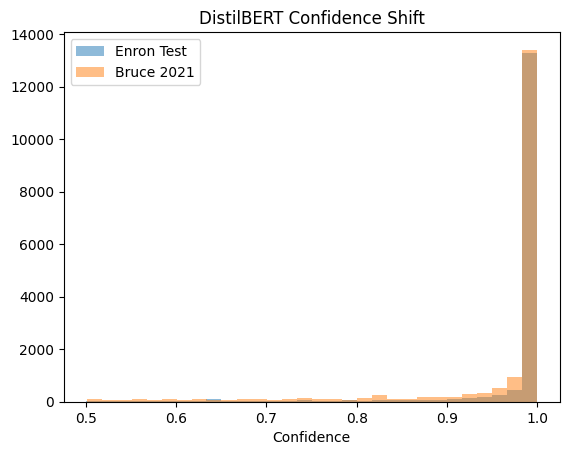

In [ ]:
import matplotlib.pyplot as plt

plt.hist(bert_val_conf, bins=30, alpha=0.5, label="Enron Test")
plt.hist(bert_test_conf, bins=30, alpha=0.5, label="Bruce 2021")
plt.legend()
plt.xlabel("Confidence")
plt.title("DistilBERT Confidence Shift")
plt.show()

In [ ]:
def get_probabilities(model, dataloader, device):
    model.eval()
    probs = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            outputs = model(input_ids=input_ids,
                            attention_mask=attention_mask)

            logits = outputs.logits
            probabilities = torch.softmax(logits, dim=1)[:, 1]

            probs.extend(probabilities.cpu().numpy())

    return np.array(probs)

In [ ]:
from sklearn.metrics import brier_score_loss

val_probs = get_probabilities(model, val_dataloader, device)
test_probs = get_probabilities(model, test_dataloader, device)



In [ ]:
val_brier = brier_score_loss(y_test, val_probs)
test_brier = brier_score_loss(spam_df[:len(test_probs)], test_probs)

print("Validation Brier score:", val_brier)
print("Test Brier score:", test_brier)
print("Brier shift:", test_brier - val_brier)

Validation Brier score: 0.11841939284888979
Test Brier score: 0.6660639456155989
Brier shift: 0.5476445527667091


# Semantic Embedding & Topic Modelling for Concept Drift Detection

This section implements an unsupervised drift detection layer using:
- **Sentence-BERT** (`all-MiniLM-L6-v2`) for dense semantic email representations
- **LDA** topic modelling to establish a baseline topic distribution over the training corpus
- **Jensen-Shannon divergence** to measure semantic shift between the training baseline and incoming monthly batches
- Drift signalling, divergent topic isolation, low-confidence flagging, and longitudinal logging

In [ ]:
!pip install sentence-transformers scikit-learn -q

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sentence_transformers import SentenceTransformer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
from scipy.spatial.distance import jensenshannon

Prepare Training Corpus and Incoming Monthly Batches

In [ ]:
# Re-use temporally split dataframes from earlier
# train_df  = Enron emails <= 2002 (baseline)
# test_df   = Enron emails > 2002  (incoming stream)

train_texts = (train_df['Subject'].fillna('') + ' ' + train_df['Message'].fillna('')).tolist()
test_texts  = (test_df['Subject'].fillna('')  + ' ' + test_df['Message'].fillna('')).tolist()

# Create rolling monthly batches from test_df
test_df_copy = test_df.copy()
test_df_copy['YearMonth'] = test_df_copy['Date'].dt.to_period('M')
monthly_batches = {
    str(period): group[['text', 'label']].copy()
    for period, group in test_df_copy.groupby('YearMonth')
}

print(f'Training corpus size     : {len(train_texts):,}')
print(f'Incoming stream size     : {len(test_texts):,}')
print(f'Number of monthly batches: {len(monthly_batches)}')
print('Sample batch keys:', list(monthly_batches.keys())[:5])

Training corpus size     : 17,868
Incoming stream size     : 15,477
Number of monthly batches: 26
Sample batch keys: ['2003-01', '2003-06', '2003-07', '2003-11', '2003-12']


##Encode Emails with Sentence-BERT
using  `all-MiniLM-L6-v2`, a lightweight Sentence-BERT model, to produce 384-dimensional
semantic embeddings. These capture semantic intent rather than surface token patterns,
making them sensitive to narrative-level drift (e.g. financial phishing -> health spam).

In [ ]:
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')

print('Encoding training corpus (sample of 3000 for speed)...')
train_sample = [t[:512] for t in train_texts[:3000]]
train_embeddings = sbert_model.encode(
    train_sample, batch_size=64, show_progress_bar=True, convert_to_numpy=True
)

print(f'Training embeddings shape: {train_embeddings.shape}')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding training corpus (sample of 3000 for speed)...


Batches:   0%|          | 0/47 [00:00<?, ?it/s]

Training embeddings shape: (3000, 384)


## Fit LDA Topic Model on Training Corpus

An LDA model is fitted on the training corpus to establish a **baseline topic distribution**.
Each document is a probability vector over K topics; the mean across all training documents
forms the reference distribution against which incoming batches are compared.

In [ ]:
N_TOPICS = 15  # Tunable — more topics = finer semantic resolution

vectorizer = CountVectorizer(
    max_features=5000,
    stop_words='english',
    min_df=3,
    max_df=0.90,
    ngram_range=(1, 1)
)

train_dtm = vectorizer.fit_transform(train_sample)

lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    random_state=42,
    max_iter=20,
    learning_method='online'
)
lda.fit(train_dtm)

# Baseline distribution: mean doc-topic vector over training set
train_topic_dist   = lda.transform(train_dtm)
baseline_topic_dist = train_topic_dist.mean(axis=0)
baseline_topic_dist /= baseline_topic_dist.sum()

print('Baseline topic distribution (prob per topic):')
for i, p in enumerate(baseline_topic_dist):
    print(f'  Topic {i:02d}: {p:.4f}')

Baseline topic distribution (prob per topic):
  Topic 00: 0.0313
  Topic 01: 0.0393
  Topic 02: 0.1459
  Topic 03: 0.0234
  Topic 04: 0.0886
  Topic 05: 0.0202
  Topic 06: 0.0140
  Topic 07: 0.0676
  Topic 08: 0.1037
  Topic 09: 0.1521
  Topic 10: 0.0535
  Topic 11: 0.0172
  Topic 12: 0.0187
  Topic 13: 0.0752
  Topic 14: 0.1493


In [ ]:
# Inspect top words per topic for interpretability
feature_names = vectorizer.get_feature_names_out()

def print_top_words(model, feature_names, n_top=8):
    print('Top words per LDA topic (training baseline):')
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top - 1:-1]]
        print(f'  Topic {topic_idx:02d}: {", ".join(top_words)}')

print_top_words(lda, feature_names)

Top words per LDA topic (training baseline):
  Topic 00: com, message, email, fw, net, order, original, mail
  Topic 01: gas, daily, calpine, nomination, 713, doc, 830, supply
  Topic 02: deal, meter, daren, gas, 00, volume, 99, thanks
  Topic 03: change, cp, sitara, forward, different, storage, valero, error
  Topic 04: 2001, 000, mmbtu, hpl, gas, nomination, 00, eastrans
  Topic 05: transport, contract, scheduling, 00, rate, el, contracts, apache
  Topic 06: txu, attached, big, tufco, star, lone, cowboy, sds
  Topic 07: th, questions, plant, texas, thanks, mark, contact, duke
  Topic 08: know, let, need, time, week, just, thanks, like
  Topic 09: ect, hou, enron, 2000, pm, cc, subject, forwarded
  Topic 10: ena, report, new, request, list, information, enron, use
  Topic 11: fee, survey, activity, hours, 2000, attached, starting, offer
  Topic 12: tenaska, iv, pec, 10, energy, cornhusker, sandi, cleburne
  Topic 13: hpl, enron, 000, teco, 2000, tap, actuals, tu
  Topic 14: xls, 2000,

## Jensen-Shannon Divergence Drift Monitor

For each incoming monthly batch:
1. Transform the batch through the *frozen* LDA model.
2. Compute Jensen-Shannon divergence between the batch mean topic vector and the baseline.
3. Compare JS divergence to a threshold — if exceeded, a drift signal is triggered.
4. Identify which topics are contributing most to the divergence for interpretable reporting.

In [ ]:
JS_THRESHOLD = 0.05   # Tunable: lower = more sensitive
WINDOW_SIZE  = 100    # Minimum batch size to evaluate drift

drift_log = []

def compute_js_divergence(p, q):
    p = np.asarray(p, dtype=float) + 1e-10
    q = np.asarray(q, dtype=float) + 1e-10
    p /= p.sum(); q /= q.sum()
    return float(jensenshannon(p, q))


def detect_drift(batch_texts, batch_labels, period_label, baseline_dist,
                 vectorizer, lda_model, threshold=JS_THRESHOLD):
    if len(batch_texts) < WINDOW_SIZE:
        return None

    texts_clean = [str(t)[:512] for t in batch_texts]
    dtm = vectorizer.transform(texts_clean)
    topic_dist = lda_model.transform(dtm).mean(axis=0)
    topic_dist /= topic_dist.sum()

    js_div = compute_js_divergence(baseline_dist, topic_dist)
    drift  = js_div > threshold

    topic_delta     = np.abs(topic_dist - baseline_dist)
    divergent_topics = np.argsort(topic_delta)[::-1][:3].tolist()

    return {
        'period'           : period_label,
        'n_emails'         : len(batch_texts),
        'js_divergence'    : round(js_div, 5),
        'drift_detected'   : drift,
        'batch_topic_dist' : topic_dist.tolist(),
        'divergent_topics' : divergent_topics,
        'spam_rate'        : float(np.mean(batch_labels)) if batch_labels is not None else None
    }


In [ ]:
# Run drift monitor across all monthly batches
for period, batch_df in sorted(monthly_batches.items()):
    result = detect_drift(
        batch_df['text'].tolist(),
        batch_df['label'].tolist(),
        period_label=period,
        baseline_dist=baseline_topic_dist,
        vectorizer=vectorizer,
        lda_model=lda
    )
    if result is not None:
        drift_log.append(result)
        status = 'DRIFT DETECTED' if result['drift_detected'] else 'stable'
        print(f"{result['period']}  JS={result['js_divergence']:.4f}  "
              f"n={result['n_emails']:4d}  {status}")

2004-01  JS=0.3805  n= 201  DRIFT DETECTED
2004-02  JS=0.3711  n= 207  DRIFT DETECTED
2004-03  JS=0.3604  n= 206  DRIFT DETECTED
2004-04  JS=0.3474  n= 274  DRIFT DETECTED
2004-05  JS=0.3472  n= 291  DRIFT DETECTED
2004-06  JS=0.3541  n= 261  DRIFT DETECTED
2004-07  JS=0.3648  n= 305  DRIFT DETECTED
2004-08  JS=0.3606  n= 698  DRIFT DETECTED
2004-09  JS=0.3662  n= 694  DRIFT DETECTED
2004-10  JS=0.3657  n= 842  DRIFT DETECTED
2004-11  JS=0.3600  n= 917  DRIFT DETECTED
2004-12  JS=0.3628  n= 945  DRIFT DETECTED
2005-01  JS=0.3688  n=1048  DRIFT DETECTED
2005-02  JS=0.3646  n= 928  DRIFT DETECTED
2005-03  JS=0.3729  n= 777  DRIFT DETECTED
2005-04  JS=0.3630  n= 776  DRIFT DETECTED
2005-05  JS=0.3826  n= 708  DRIFT DETECTED
2005-06  JS=0.4042  n=2167  DRIFT DETECTED
2005-07  JS=0.3828  n=2888  DRIFT DETECTED
2005-08  JS=0.3740  n= 191  DRIFT DETECTED


## Visualise Drift Over Time

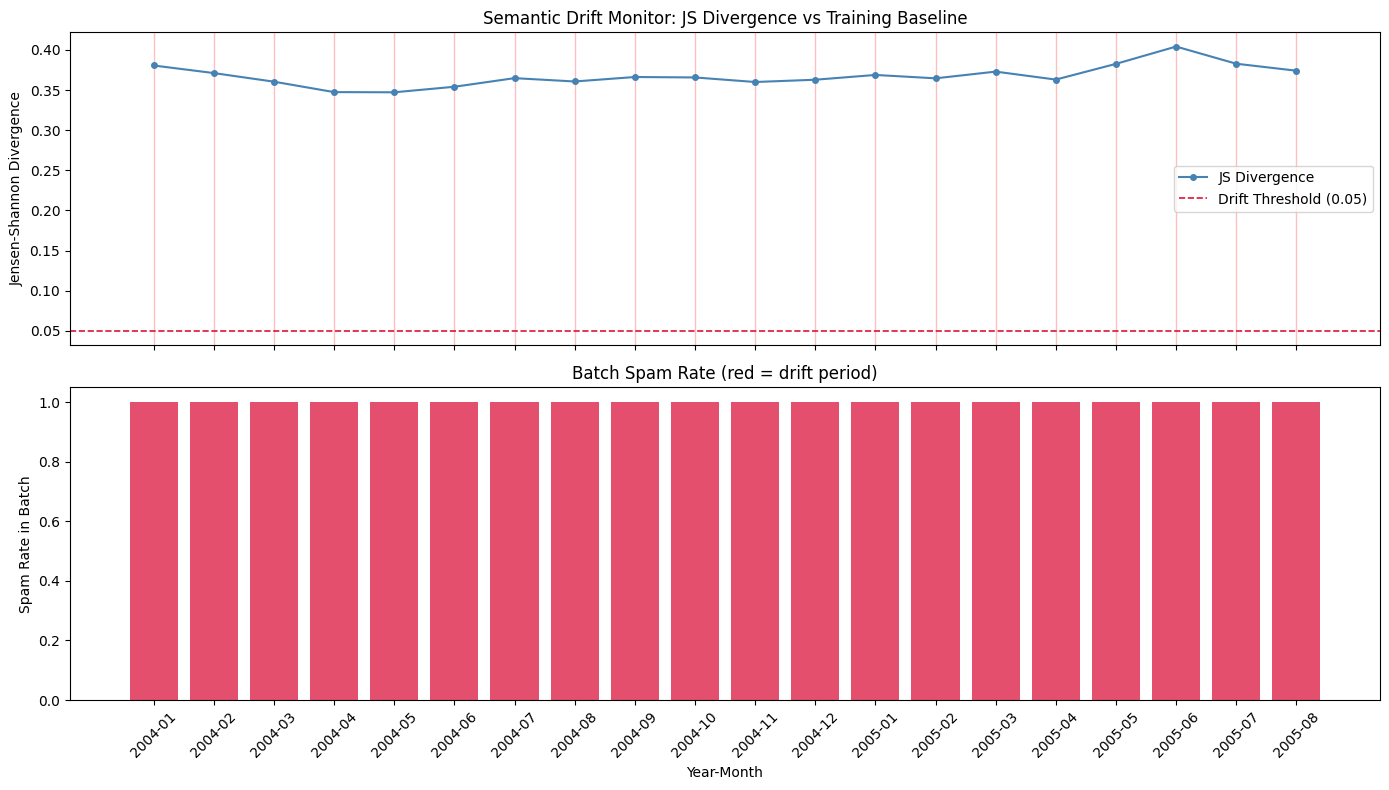

Saved: drift_monitor.png


In [ ]:
drift_df = pd.DataFrame(drift_log)
drift_df['period'] = drift_df['period'].astype(str)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax = axes[0]
ax.plot(drift_df['period'], drift_df['js_divergence'], marker='o',
        color='steelblue', linewidth=1.5, markersize=4, label='JS Divergence')
ax.axhline(JS_THRESHOLD, color='crimson', linestyle='--', linewidth=1.2,
           label=f'Drift Threshold ({JS_THRESHOLD})')
for _, row in drift_df[drift_df['drift_detected']].iterrows():
    ax.axvspan(row['period'], row['period'], alpha=0.25, color='red')
ax.set_ylabel('Jensen-Shannon Divergence')
ax.set_title('Semantic Drift Monitor: JS Divergence vs Training Baseline')
ax.legend()
ax.tick_params(axis='x', rotation=45)

ax2 = axes[1]
colors_bar = ['crimson' if d else 'steelblue' for d in drift_df['drift_detected']]
ax2.bar(drift_df['period'], drift_df['spam_rate'], color=colors_bar, alpha=0.75, width=0.8)
ax2.set_ylabel('Spam Rate in Batch')
ax2.set_xlabel('Year-Month')
ax2.set_title('Batch Spam Rate (red = drift period)')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('drift_monitor.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: drift_monitor.png')

In [ ]:
n_drift  = drift_df['drift_detected'].sum()
n_stable = (~drift_df['drift_detected']).sum()
max_row  = drift_df.loc[drift_df['js_divergence'].idxmax()]

print('=== Drift Detection Summary ===')
print(f'Total batches evaluated : {len(drift_df)}')
print(f'Drift detected          : {n_drift}  ({100*n_drift/len(drift_df):.1f}%)')
print(f'Stable batches          : {n_stable}')
print(f'Max JS divergence       : {max_row["js_divergence"]:.5f} ({max_row["period"]})')
print()
print('Periods flagged for drift with leading divergent topic:')
for _, row in drift_df[drift_df['drift_detected']].iterrows():
    tid   = row['divergent_topics'][0]
    words = [feature_names[i] for i in lda.components_[tid].argsort()[:-6:-1]]
    print(f"  {row['period']}  JS={row['js_divergence']:.4f}  "
          f"Leading topic {tid}: {', '.join(words)}")

=== Drift Detection Summary ===
Total batches evaluated : 20
Drift detected          : 20  (100.0%)
Stable batches          : 0
Max JS divergence       : 0.40415 (2005-06)

Periods flagged for drift with leading divergent topic:
  2004-01  JS=0.3805  Leading topic 8: know, let, need, time, week
  2004-02  JS=0.3711  Leading topic 8: know, let, need, time, week
  2004-03  JS=0.3604  Leading topic 8: know, let, need, time, week
  2004-04  JS=0.3474  Leading topic 8: know, let, need, time, week
  2004-05  JS=0.3472  Leading topic 8: know, let, need, time, week
  2004-06  JS=0.3541  Leading topic 8: know, let, need, time, week
  2004-07  JS=0.3648  Leading topic 8: know, let, need, time, week
  2004-08  JS=0.3606  Leading topic 8: know, let, need, time, week
  2004-09  JS=0.3662  Leading topic 8: know, let, need, time, week
  2004-10  JS=0.3657  Leading topic 8: know, let, need, time, week
  2004-11  JS=0.3600  Leading topic 8: know, let, need, time, week
  2004-12  JS=0.3628  Leading topi

In [ ]:
# Low-confidence flagging for drift periods
drift_periods = set(drift_df[drift_df['drift_detected']]['period'].tolist())

test_df_reset = test_df.copy().reset_index(drop=True)
test_df_reset['YearMonth'] = test_df_reset['Date'].dt.to_period('M').astype(str)
test_df_reset['drift_flag'] = test_df_reset['YearMonth'].isin(drift_periods)

print(f'Emails in drift periods  : {test_df_reset["drift_flag"].sum():,}')
print(f'Emails in stable periods : {(~test_df_reset["drift_flag"]).sum():,}')
print('Sample flagged records:')
test_df_reset[test_df_reset['drift_flag']][['Date', 'YearMonth', 'label', 'drift_flag']].head(5)

Emails in drift periods  : 15,324
Emails in stable periods : 153
Sample flagged records:


,Date,YearMonth,label,drift_flag
32,2004-01-03,2004-01,1,True
33,2004-01-03,2004-01,1,True
34,2004-01-04,2004-01,1,True
35,2004-01-04,2004-01,1,True
36,2004-01-06,2004-01,1,True


In [ ]:
# Export longitudinal drift log
drift_df[['period', 'n_emails', 'js_divergence', 'drift_detected',
          'divergent_topics', 'spam_rate']].to_csv('drift_log.csv', index=False)
print('Drift log saved to drift_log.csv')
drift_df[['period', 'n_emails', 'js_divergence', 'drift_detected', 'spam_rate']].round(4)

Drift log saved to drift_log.csv


,period,n_emails,js_divergence,drift_detected,spam_rate
0,2004-01,201,0.3806,True,1.0
1,2004-02,207,0.3711,True,1.0
2,2004-03,206,0.3604,True,1.0
3,2004-04,274,0.3474,True,1.0
4,2004-05,291,0.3472,True,1.0
5,2004-06,261,0.3541,True,1.0
6,2004-07,305,0.3648,True,1.0
7,2004-08,698,0.3606,True,1.0
8,2004-09,694,0.3662,True,1.0
9,2004-10,842,0.3657,True,1.0


---
#LLM-Based Probability Refinement

This section implements a **two-stage hybrid inference system**:

1. **Stage 1 — Base classifier** (DistilBERT): produces an initial spam probability for every email.
2. **Stage 2 — LLM auditor** (`gpt-4o-mini` via OPENAI API): invoked *selectively* on
   uncertain or drift-flagged emails to output a calibrated secondary probability estimate.

The final decision is a weighted blend:
$$p_{\text{final}} = w_{\text{base}} \cdot p_{\text{BERT}} + w_{\text{LLM}} \cdot p_{\text{LLM}}$$

High-confidence predictions bypass the LLM entirely, preserving computational efficiency.

In [ ]:
!pip install openai -q

In [ ]:
import openai
import re
import time

# Set your OpenAI API key via Colab secrets or environment variable:
#   from google.colab import userdata
#   OPENAI_API_KEY = userdata.get('OPENAI_API_KEY')
#   -- OR --
#   import os; os.environ['OPENAI_API_KEY'] = 'sk-...'

try:
    from google.colab import userdata
    OPENAI_API_KEY = userdata.get('OPENAI_API_KEY')
except Exception:
    import os
    OPENAI_API_KEY = os.environ.get('OPENAI_API_KEY', '')

if not OPENAI_API_KEY:
    print('[WARNING] OPENAI_API_KEY not set. LLM refinement calls will be skipped.')
else:
    openai.api_key = OPENAI_API_KEY
    print('OpenAI API key found.')

OpenAI API key found.


##Collect DistilBERT Probabilities and Identify Uncertainty Band

We run DistilBERT across the test set and identify two routing criteria:
- **Uncertainty band**: `0.30 <= p(spam) <= 0.70` — the model is insufficiently confident.
- **Drift flag**: the email falls in a period where JS divergence exceeded the threshold.

Only emails meeting at least one criterion are forwarded to the LLM layer.

In [ ]:
UNCERTAINTY_LOW  = 0.30
UNCERTAINTY_HIGH = 0.70
LLM_WEIGHT  = 0.40   # Weight of LLM estimate in final blend
BASE_WEIGHT = 0.60   # Weight of DistilBERT estimate


def get_bert_probs_batch(texts, model, tokenizer, device, batch_size=32):
    model.eval()
    all_probs = []
    texts_clean = [str(t)[:512] for t in texts]
    for i in range(0, len(texts_clean), batch_size):
        batch = texts_clean[i:i+batch_size]
        enc = tokenizer(
            batch, truncation=True, padding=True,
            max_length=256, return_tensors='pt'
        ).to(device)
        with torch.no_grad():
            logits = model(**enc).logits
            probs  = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        all_probs.extend(probs)
    return np.array(all_probs)


print('Getting DistilBERT probabilities on temporal test set...')
bert_test_probs = get_bert_probs_batch(
    test_df['text'].tolist(), model, tokenizer, device
)

# Routing masks
uncertain_mask = (
    (bert_test_probs >= UNCERTAINTY_LOW) &
    (bert_test_probs <= UNCERTAINTY_HIGH)
)
drift_mask = test_df_reset['drift_flag'].values
refinement_mask = uncertain_mask | drift_mask

print(f'Total test emails          : {len(bert_test_probs):,}')
print(f'Uncertainty band emails    : {uncertain_mask.sum():,}')
print(f'Drift-period emails        : {drift_mask.sum():,}')
print(f'Emails routed to LLM layer : {refinement_mask.sum():,}  '
      f'({100*refinement_mask.mean():.1f}% of test set)')

Getting DistilBERT probabilities on temporal test set...
Total test emails          : 15,477
Uncertainty band emails    : 508
Drift-period emails        : 15,324
Emails routed to LLM layer : 15,327  (99.0% of test set)


##LLM Probability Refinement Function

Each routed email is sent to `gpt-4o-mini` with a structured prompt that provides the
email content, the base model probability, and explicit reasoning instructions. The model
outputs a calibrated probability using a parseable format.

In [ ]:
SYSTEM_PROMPT = """\
You are a spam detection calibration assistant.
Given an email and a base model spam probability, your task is to:
1. Reason briefly about the email's content, tone, intent, and spam indicators.
2. Output a CALIBRATED spam probability between 0.0 and 1.0 as a single float.

Focus especially on:
- Persuasion tactics, urgency language, or financial lures
- Suspicious sender patterns, off-topic padding, or obfuscated text
- Phishing narratives or health/financial content patterns

End your response with EXACTLY this line:
CALIBRATED_PROBABILITY: <float between 0.0 and 1.0>
"""


def extract_probability(text):
    match = re.search(r'CALIBRATED_PROBABILITY:\s*([0-9]*\.?[0-9]+)', text)
    if match:
        return float(np.clip(float(match.group(1)), 0.0, 1.0))
    return None


def llm_refine_probability(email_text, base_prob, client, max_retries=2):
    user_message = (
        f'Email text (truncated to 600 chars):\n{str(email_text)[:600]}\n\n'
        f'Base model spam probability: {base_prob:.4f}\n\n'
        f'Please reason about this email and provide your calibrated probability.'
    )
    for attempt in range(max_retries):
        try:
            response = client.chat.completions.create(
                model='gpt-4o-mini',
                max_tokens=300,
                messages=[
                    {'role': 'system', 'content': SYSTEM_PROMPT},
                    {'role': 'user',   'content': user_message}
                ]
            )
            reply = response.choices[0].message.content
            prob  = extract_probability(reply)
            if prob is not None:
                return prob, reply
        except Exception as e:
            if attempt < max_retries - 1:
                time.sleep(1)
            else:
                print(f'  [LLM call failed]: {e}')
    return None, None

print('LLM refinement function defined.')

LLM refinement function defined.


## Run the Two-Stage Hybrid Pipeline

The LLM is invoked on a capped sample of routed emails to control API cost during experiments
(increase `MAX_LLM_CALLS` for full evaluation). The final probability blends both estimates.

In [ ]:
MAX_LLM_CALLS = 30   # Increase for full evaluation; kept low to control API cost

results_hybrid = []

if not OPENAI_API_KEY:
    print('[SKIP] No API key set. Assign OPENAI_API_KEY to run the LLM layer.')
else:
    client = openai.OpenAI(api_key=OPENAI_API_KEY)
    routed_indices = np.where(refinement_mask)[0][:MAX_LLM_CALLS]
    print(f'Running LLM refinement on {len(routed_indices)} emails...\n')

    for idx in routed_indices:
        email_text = test_df_reset.loc[idx, 'text']
        true_label = int(test_df_reset.loc[idx, 'label'])
        base_p     = float(bert_test_probs[idx])
        year_month = test_df_reset.loc[idx, 'YearMonth']

        llm_p, llm_reasoning = llm_refine_probability(email_text, base_p, client)

        final_p = (BASE_WEIGHT * base_p + LLM_WEIGHT * llm_p) if llm_p is not None else base_p

        results_hybrid.append({
            'index'         : idx,
            'period'        : year_month,
            'true_label'    : true_label,
            'base_prob'     : base_p,
            'llm_prob'      : llm_p,
            'final_prob'    : final_p,
            'drift_flagged' : bool(drift_mask[idx]),
            'uncertain'     : bool(uncertain_mask[idx]),
            'base_correct'  : int((base_p  >= 0.5) == true_label),
            'final_correct' : int((final_p >= 0.5) == true_label)
        })

        llm_str = f'{llm_p:.3f}' if llm_p is not None else 'N/A'
        print(f'  [{idx:4d}]  true={true_label}  base={base_p:.3f}  '
              f'llm={llm_str:>5}  final={final_p:.3f}  drift={drift_mask[idx]}')

    print(f'\nLLM refinement complete: {len(results_hybrid)} emails processed.')

Running LLM refinement on 30 emails...

  [  10]  true=1  base=0.463  llm=0.785  final=0.592  drift=False
  [  32]  true=1  base=0.823  llm=0.750  final=0.794  drift=True
  [  33]  true=1  base=0.999  llm=1.000  final=1.000  drift=True
  [  34]  true=1  base=0.999  llm=1.000  final=0.999  drift=True
  [  35]  true=1  base=0.999  llm=1.000  final=0.999  drift=True
  [  36]  true=1  base=0.999  llm=1.000  final=0.999  drift=True
  [  37]  true=1  base=0.999  llm=1.000  final=0.999  drift=True
  [  38]  true=1  base=0.999  llm=0.999  final=0.999  drift=True
  [  39]  true=1  base=0.999  llm=0.999  final=0.999  drift=True
  [  40]  true=1  base=0.001  llm=0.750  final=0.300  drift=True
  [  41]  true=1  base=0.999  llm=1.000  final=1.000  drift=True
  [  42]  true=1  base=0.996  llm=0.998  final=0.997  drift=True
  [  43]  true=1  base=0.964  llm=0.975  final=0.968  drift=True
  [  44]  true=1  base=0.914  llm=0.950  final=0.928  drift=True
  [  45]  true=1  base=0.001  llm=0.850  final=0.

##Calibration Analysis — Brier Score and Log-Loss

In [ ]:
from sklearn.metrics import brier_score_loss, log_loss

if results_hybrid:
    hybrid_df   = pd.DataFrame(results_hybrid)
    y_true      = hybrid_df['true_label'].values
    base_probs  = hybrid_df['base_prob'].values
    final_probs = hybrid_df['final_prob'].values

    base_brier  = brier_score_loss(y_true, base_probs)
    final_brier = brier_score_loss(y_true, final_probs)
    base_acc    = hybrid_df['base_correct'].mean()
    final_acc   = hybrid_df['final_correct'].mean()

    try:
        base_ll  = log_loss(y_true, np.clip(base_probs, 1e-7, 1-1e-7))
        final_ll = log_loss(y_true, np.clip(final_probs, 1e-7, 1-1e-7))
    except Exception:
        base_ll = final_ll = float('nan')

    print('===== Two-Stage Hybrid Pipeline: Calibration Results =====')
    print(f'  Emails evaluated       : {len(hybrid_df)}')
    print(f'  Drift-flagged          : {hybrid_df["drift_flagged"].sum()}')
    print(f'  Uncertainty-band       : {hybrid_df["uncertain"].sum()}')
    print()
    print(f'  Base DistilBERT Brier  : {base_brier:.5f}')
    print(f'  Hybrid (LLM-blended)   : {final_brier:.5f}')
    print(f'  Brier improvement      : {base_brier - final_brier:+.5f}')
    print()
    print(f'  Base log-loss          : {base_ll:.5f}')
    print(f'  Hybrid log-loss        : {final_ll:.5f}')
    print()
    print(f'  Base accuracy (sample) : {base_acc:.3f}')
    print(f'  Hybrid accuracy        : {final_acc:.3f}')
else:
    print('[SKIP] No hybrid results. Set OPEN_AI_KEY and re-run.')

===== Two-Stage Hybrid Pipeline: Calibration Results =====
  Emails evaluated       : 30
  Drift-flagged          : 29
  Uncertainty-band       : 1

  Base DistilBERT Brier  : 0.11089
  Hybrid (LLM-blended)   : 0.05531
  Brier improvement      : +0.05559

  Base log-loss          : nan
  Hybrid log-loss        : nan

  Base accuracy (sample) : 0.867
  Hybrid accuracy        : 0.900


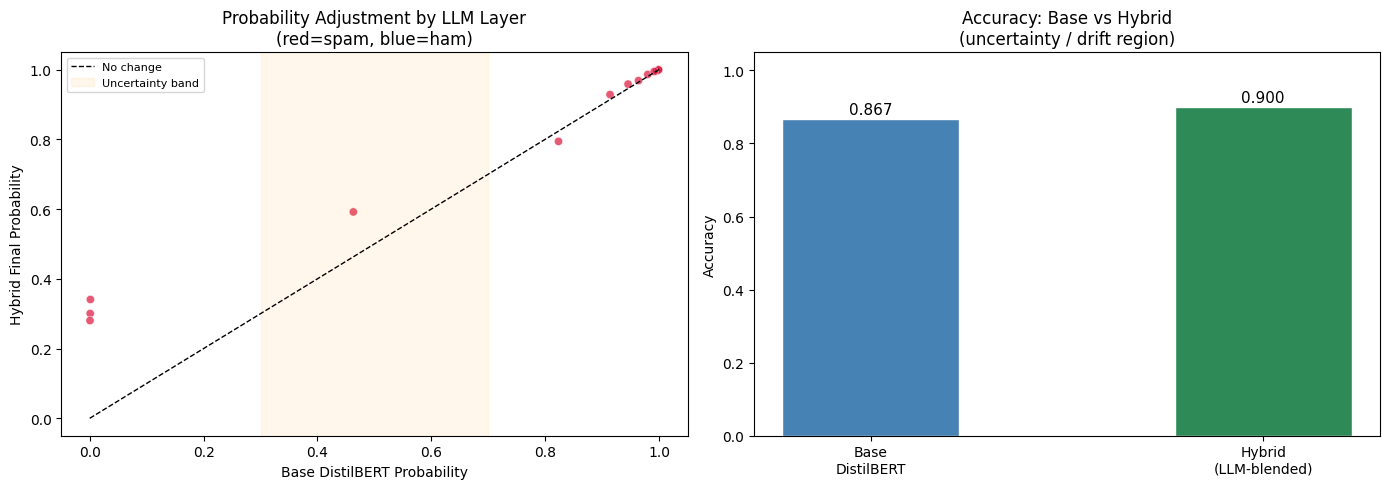

Saved: hybrid_refinement.png


In [ ]:
if results_hybrid:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # --- Scatter: base vs hybrid probabilities ---
    ax = axes[0]
    colors = ['crimson' if l == 1 else 'steelblue' for l in hybrid_df['true_label']]
    ax.scatter(hybrid_df['base_prob'], hybrid_df['final_prob'],
               c=colors, alpha=0.7, edgecolors='white', linewidths=0.5)
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='No change')
    ax.axvspan(UNCERTAINTY_LOW, UNCERTAINTY_HIGH, alpha=0.08, color='orange',
               label='Uncertainty band')
    ax.set_xlabel('Base DistilBERT Probability')
    ax.set_ylabel('Hybrid Final Probability')
    ax.set_title('Probability Adjustment by LLM Layer\n(red=spam, blue=ham)')
    ax.legend(fontsize=8)

    # --- Bar: accuracy comparison ---
    ax2 = axes[1]
    labels_bar = ['Base\nDistilBERT', 'Hybrid\n(LLM-blended)']
    values_bar = [base_acc, final_acc]
    bars = ax2.bar(labels_bar, values_bar,
                   color=['steelblue', 'seagreen'], width=0.45, edgecolor='white')
    for bar, val in zip(bars, values_bar):
        ax2.text(bar.get_x() + bar.get_width()/2, val + 0.005,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=11)
    ax2.set_ylim(0, 1.05)
    ax2.set_ylabel('Accuracy')
    ax2.set_title('Accuracy: Base vs Hybrid\n(uncertainty / drift region)')

    plt.tight_layout()
    plt.savefig('hybrid_refinement.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: hybrid_refinement.png')
else:
    print('[SKIP] Set OPENAI_API_KEY to generate visualisations.')

##Full Pipeline Decision Table

Each row shows the routing decision, base probability, LLM calibration, final blended probability,
whether drift or uncertainty triggered LLM routing, and per-email accuracy gain.

In [ ]:
if results_hybrid:
    pd.set_option('display.float_format', '{:.4f}'.format)
    cols = ['period', 'true_label', 'base_prob', 'llm_prob', 'final_prob',
            'drift_flagged', 'uncertain', 'base_correct', 'final_correct']
    hybrid_df[cols].round(4)
else:
    print('[SKIP] No results available. Run with OPENAI_API_KEY set.')

In [ ]:
if results_hybrid:
    hybrid_df.to_csv('hybrid_refinement_results.csv', index=False)
    print('Hybrid refinement results saved to hybrid_refinement_results.csv')

Hybrid refinement results saved to hybrid_refinement_results.csv


## Shap
SHAP (SHapley Additive exPlanations) assigns each feature a contribution score to a specific prediction, grounded in cooperative game theory.

In [ ]:
def evaluate_bert_probs(texts):
    """Wrapper for SHAP — takes a list of strings, returns (n, 2) probability array."""
    probs_spam = get_bert_probs_batch(texts, model, tokenizer, device)
    probs_ham  = 1 - probs_spam
    return np.stack([probs_ham, probs_spam], axis=1)

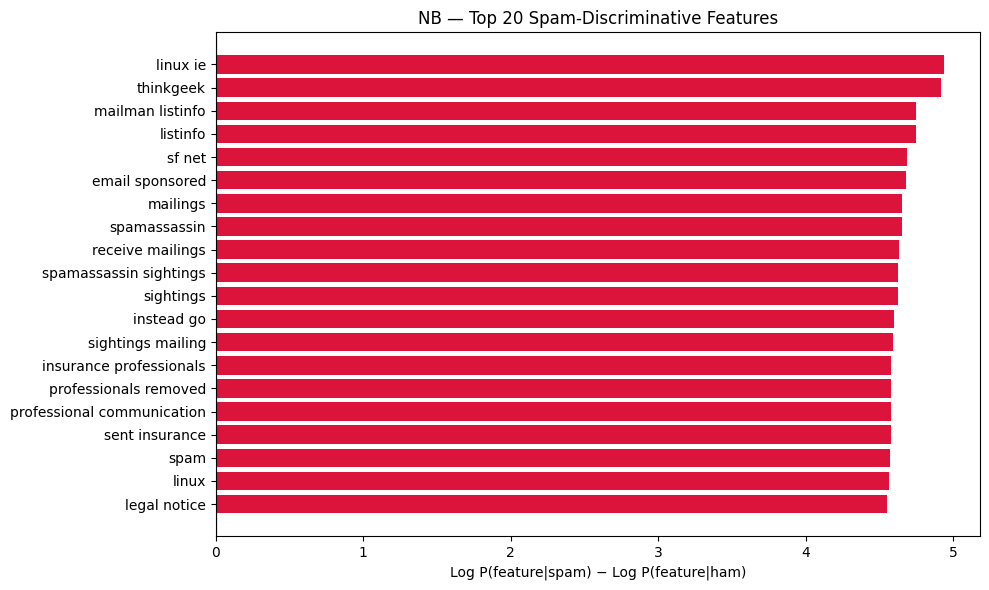

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# For MultinomialNB, feature_log_prob_ gives the log probability of each
# feature given each class. The difference between spam and ham log probs
# is directly interpretable as a spam signal strength — equivalent to SHAP.

feature_names   = nb_model["tfidf"].get_feature_names_out()
log_prob_ham    = nb_model["nb"].feature_log_prob_[0]   # P(feature | ham)
log_prob_spam   = nb_model["nb"].feature_log_prob_[1]   # P(feature | spam)

# Difference: positive = more likely in spam than ham
spam_signal = log_prob_spam - log_prob_ham

top_idx   = np.argsort(spam_signal)[-20:][::-1]
top_names = feature_names[top_idx]
top_vals  = spam_signal[top_idx]

plt.figure(figsize=(10, 6))
colors = ["crimson" if v > 0 else "steelblue" for v in top_vals]
plt.barh(top_names[::-1], top_vals[::-1], color=colors[::-1])
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Log P(feature|spam) − Log P(feature|ham)")
plt.title("NB — Top 20 Spam-Discriminative Features")
plt.tight_layout()
plt.savefig("nb_shap.png", dpi=150, bbox_inches="tight")
plt.show()

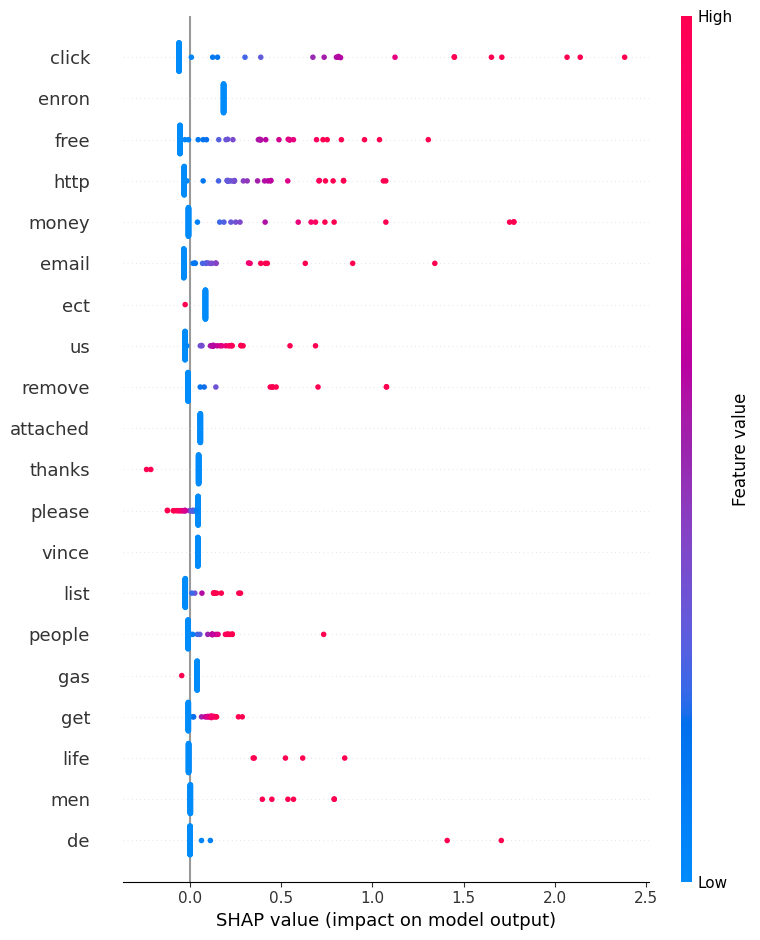

PartitionExplainer explainer: 21it [00:46,  3.09s/it]


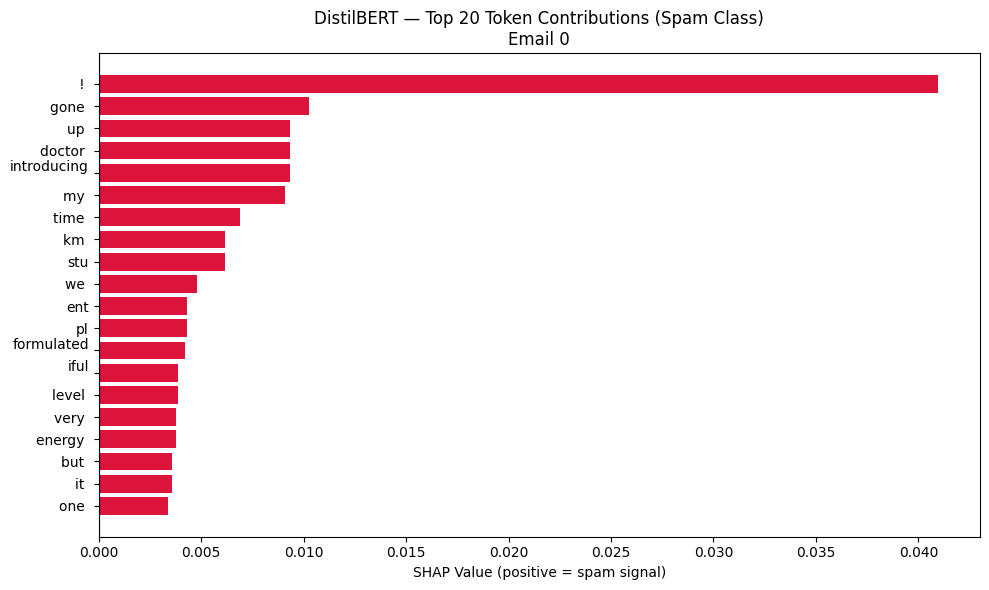

In [ ]:
import shap
import numpy as np

# ── Logistic Regression SHAP ──────────────────────────────────
X_train_tfidf_lr = lr_model["tfidf"].transform(X_train).toarray()
X_test_tfidf_lr  = lr_model["tfidf"].transform(X_test[:100]).toarray()

lr_explainer   = shap.LinearExplainer(lr_model["lr"], X_train_tfidf_lr)
lr_shap_values = lr_explainer.shap_values(X_test_tfidf_lr)

shap.summary_plot(
    lr_shap_values,
    features=X_test_tfidf_lr,
    feature_names=lr_model["tfidf"].get_feature_names_out(),
    title="LR — SHAP Feature Importance"
)

# ── DistilBERT SHAP ───────────────────────────────────────────
bert_explainer = shap.Explainer(
    lambda x: evaluate_bert_probs(x),
    shap.maskers.Text(tokenizer)
)
bert_shap_values = bert_explainer(test_df["text"][:20])
# ── DistilBERT SHAP — clean bar chart ────────────────────────
import pandas as pd

# bert_shap_values[0] = first email, output 1 = spam class
shap_vals   = bert_shap_values[0, :, 1]   # spam class SHAP values
token_names = bert_shap_values.data[0]     # corresponding tokens

# Build DataFrame and aggregate by token (same token may appear multiple times)
shap_df = pd.DataFrame({
    "token": token_names,
    "shap":  shap_vals.values
})

shap_df = (
    shap_df.groupby("token")["shap"]
    .mean()
    .reset_index()
    .sort_values("shap", key=abs, ascending=False)
    .head(20)
)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["crimson" if v > 0 else "steelblue" for v in shap_df["shap"]]
ax.barh(shap_df["token"][::-1], shap_df["shap"][::-1], color=colors[::-1])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("SHAP Value (positive = spam signal)")
ax.set_title("DistilBERT — Top 20 Token Contributions (Spam Class)\nEmail 0")
plt.tight_layout()
plt.savefig("bert_shap.png", dpi=150, bbox_inches="tight")
plt.show()

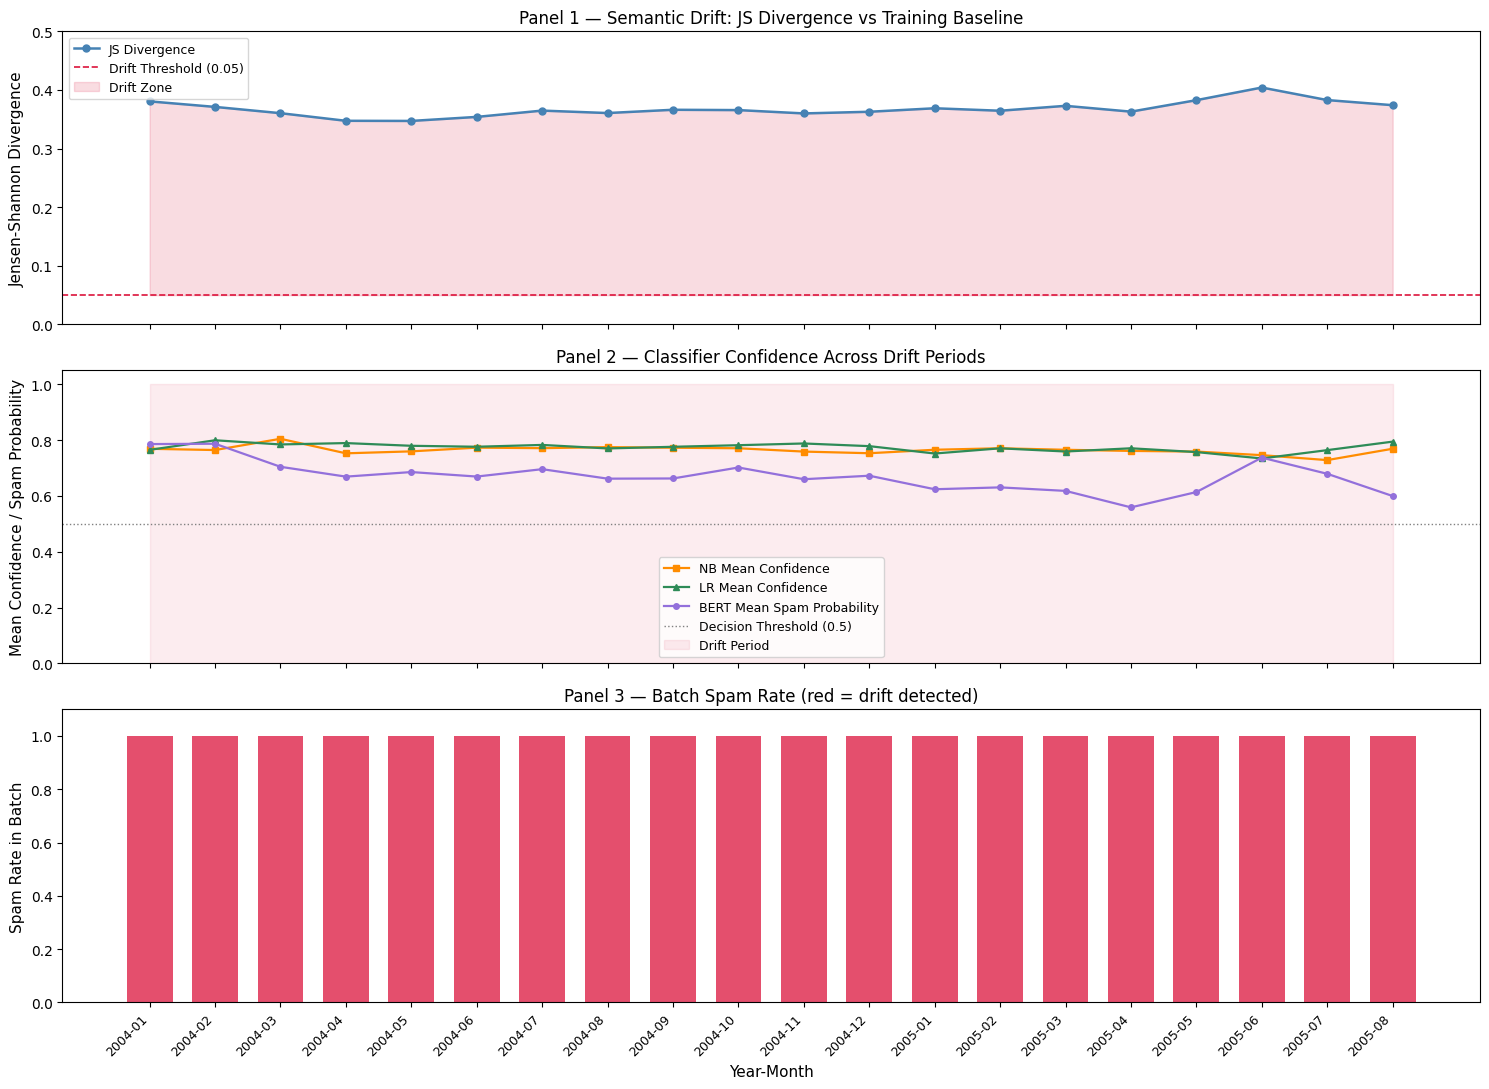

Saved: drift_monitor_extended.png


In [ ]:
# ── Extend drift_df with per-period classifier confidence ─────
for period, batch_df in sorted(monthly_batches.items()):
    batch_texts = batch_df["text"].tolist()

    # NB confidence on this batch
    nb_probs = nb_model.predict_proba(batch_texts)
    nb_conf  = nb_probs.max(axis=1).mean()

    # LR confidence on this batch
    lr_probs = lr_model.predict_proba(batch_texts)
    lr_conf  = lr_probs.max(axis=1).mean()

    # BERT mean spam probability on this batch
    bert_probs = get_bert_probs_batch(batch_texts, model, tokenizer, device)
    bert_conf  = bert_probs.mean()

    mask = drift_df["period"] == period
    drift_df.loc[mask, "nb_mean_conf"]   = nb_conf
    drift_df.loc[mask, "lr_mean_conf"]   = lr_conf
    drift_df.loc[mask, "bert_mean_prob"] = bert_conf

# ── 3-panel drift visualisation ───────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(15, 11), sharex=True)
periods = drift_df["period"].astype(str)
x       = range(len(periods))

# ── Panel 1: JS Divergence ────────────────────────────────────
ax1 = axes[0]
ax1.plot(x, drift_df["js_divergence"], marker="o", color="steelblue",
         linewidth=1.8, markersize=5, label="JS Divergence")
ax1.axhline(JS_THRESHOLD, color="crimson", linestyle="--",
            linewidth=1.2, label=f"Drift Threshold ({JS_THRESHOLD})")
ax1.fill_between(x, drift_df["js_divergence"], JS_THRESHOLD,
                 where=drift_df["drift_detected"], alpha=0.15, color="crimson",
                 label="Drift Zone")
ax1.set_ylabel("Jensen-Shannon Divergence", fontsize=11)
ax1.set_title("Panel 1 — Semantic Drift: JS Divergence vs Training Baseline", fontsize=12)
ax1.legend(fontsize=9)
ax1.set_ylim(0, 0.5)

# ── Panel 2: Classifier Confidence Over Time ──────────────────
ax2 = axes[1]
ax2.plot(x, drift_df["nb_mean_conf"],   marker="s", color="darkorange",
         linewidth=1.6, markersize=4, label="NB Mean Confidence")
ax2.plot(x, drift_df["lr_mean_conf"],   marker="^", color="seagreen",
         linewidth=1.6, markersize=4, label="LR Mean Confidence")
ax2.plot(x, drift_df["bert_mean_prob"], marker="o", color="mediumpurple",
         linewidth=1.6, markersize=4, label="BERT Mean Spam Probability")
ax2.axhline(0.5, color="grey", linestyle=":", linewidth=1.0, label="Decision Threshold (0.5)")
ax2.fill_between(x, 0, 1, where=drift_df["drift_detected"].values,
                 alpha=0.08, color="crimson", label="Drift Period")
ax2.set_ylabel("Mean Confidence / Spam Probability", fontsize=11)
ax2.set_title("Panel 2 — Classifier Confidence Across Drift Periods", fontsize=12)
ax2.legend(fontsize=9)
ax2.set_ylim(0, 1.05)

# ── Panel 3: Batch Spam Rate ──────────────────────────────────
ax3 = axes[2]
bar_colors = ["crimson" if d else "steelblue" for d in drift_df["drift_detected"]]
ax3.bar(x, drift_df["spam_rate"], color=bar_colors, alpha=0.75, width=0.7)
ax3.set_ylabel("Spam Rate in Batch", fontsize=11)
ax3.set_title("Panel 3 — Batch Spam Rate (red = drift detected)", fontsize=12)
ax3.set_ylim(0, 1.1)

# ── Shared x-axis labels ──────────────────────────────────────
ax3.set_xticks(list(x))
ax3.set_xticklabels(periods, rotation=45, ha="right", fontsize=9)
ax3.set_xlabel("Year-Month", fontsize=11)

plt.tight_layout()
plt.savefig("drift_monitor_extended.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: drift_monitor_extended.png")

In [ ]:
# Build a balanced evaluation set
n_per_class = 200

spam_eval = test_df_reset[test_df_reset["label"] == 1].sample(n_per_class, random_state=42)
ham_eval  = test_df_reset[test_df_reset["label"] == 0].sample(n_per_class, random_state=42)
eval_df   = pd.concat([spam_eval, ham_eval]).sample(frac=1, random_state=42)  # shuffle

# Run the full two-stage pipeline on eval_df
# Then compute:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(eval_df["label"], (final_probs >= 0.5).astype(int)))
print("Base AUC:  ", roc_auc_score(eval_df["label"], base_probs))
print("Hybrid AUC:", roc_auc_score(eval_df["label"], final_probs))
print("Base Brier:  ", brier_score_loss(eval_df["label"], base_probs))
print("Hybrid Brier:", brier_score_loss(eval_df["label"], final_probs))